In [2]:
import sys
sys.path.append('/Users/isaac/Documents/MASS/Academic/2nd semester/AGN/tutorials/AGN-tutorials/SciScript-Python')

from SciServer import Authentication, CasJobs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse, FancyArrowPatch
plt.style.use('seaborn-v0_8-deep')
plt.rcParams.update({'font.size': 12})

from dotenv import load_dotenv
import os

# Task 1

a) Obtain the objects and make a BPT diagram

In [3]:
load_dotenv()
username = os.getenv("SCISERVER_USER")
password = os.getenv("SCISERVER_PASS")

Authentication.login(username, password)

query = '''
    SELECT TOP 10000
        s.specobjid,s.z,
        g.oiii_5007_flux,
        g.oiii_sigma,
        g.oi_6300_flux,
        g.h_beta_flux,
        g.h_alpha_flux,
        g.h_alpha_eqw,
        g.sii_6717_flux,
        g.sii_6731_flux,
        g.nii_6584_flux,
        g.oiii_5007_flux / g.h_beta_flux   AS oiii_hbeta_ratio,
        g.nii_6584_flux  / g.h_alpha_flux  AS nii_halpha_ratio

    FROM SpecObj AS s
        JOIN GalSpecLine AS g ON s.specobjid = g.specobjid

    WHERE
        s.class      = 'GALAXY' AND
        s.z          < 0.35     AND
        s.snmedian_g > 20       AND

        -- Velocity dispersion (FWHM < 500 km/s)
        2.3548 * g.sigma_balmer < 500 AND
        2.3548 * g.oiii_sigma   < 500 AND

        -- Emission line detection (negative EQW = emission)
        g.oiii_5007_eqw  < -0.1 AND
        g.oi_6300_eqw    < -0.1 AND
        g.h_beta_eqw     < -0.1 AND
        g.h_alpha_eqw    < -0.1 AND
        g.nii_6584_eqw   < -0.1 AND
        g.sii_6717_eqw   < -0.1 AND
        g.sii_6731_eqw   < -0.1 AND

        -- Minimum absolute flux
        g.oiii_5007_flux > 5 AND
        g.oi_6300_flux   > 5 AND
        g.h_beta_flux    > 5 AND
        g.h_alpha_flux   > 5 AND
        g.nii_6584_flux  > 5 AND
        g.sii_6717_flux  > 5 AND
        g.sii_6731_flux  > 5 AND

        -- flux > 5 * flux_err for all diagnostic lines
        g.oiii_5007_flux > 5 * g.oiii_5007_flux_err AND
        g.oi_6300_flux   > 5 * g.oi_6300_flux_err   AND
        g.h_beta_flux    > 5 * g.h_beta_flux_err     AND
        g.h_alpha_flux   > 5 * g.h_alpha_flux_err    AND
        g.nii_6584_flux  > 5 * g.nii_6584_flux_err  AND
        g.sii_6717_flux  > 5 * g.sii_6717_flux_err  AND
        g.sii_6731_flux  > 5 * g.sii_6731_flux_err

        ORDER BY s.specobjid
'''

result = CasJobs.executeQuery(query, context='DR18')
result.to_csv('agn_sample.csv', index=False)

In [4]:
result = pd.read_csv('agn_sample.csv')
len(result)

10000

In [5]:
result.head()

,specobjid,z,oiii_5007_flux,oiii_sigma,oi_6300_flux,h_beta_flux,h_alpha_flux,h_alpha_eqw,sii_6717_flux,sii_6731_flux,nii_6584_flux,oiii_hbeta_ratio,nii_halpha_ratio
0,299529534741440512,0.052176,86.13953,81.74523,44.57067,266.44600,1334.9670,-36.253700,210.0699,146.98770,489.7381,0.323291,0.366854
1,299532558398416896,0.021758,780.11430,50.68575,59.05846,638.05270,2292.5280,-56.841010,430.3535,299.65790,465.8451,1.222649,0.203202
2,299607600067012608,0.025250,49.28839,82.53763,19.15328,70.19812,374.9436,-9.190491,82.4512,54.95967,198.3827,0.702133,0.529100
3,299638661270497280,0.020076,70.22443,110.51870,48.40514,156.39040,853.0652,-12.626060,187.3937,140.81030,515.1613,0.449033,0.603894
4,299639211026311168,0.030533,1053.11200,58.27615,62.74306,612.72800,2139.6950,-80.606770,343.9395,244.86470,351.6221,1.718728,0.164333


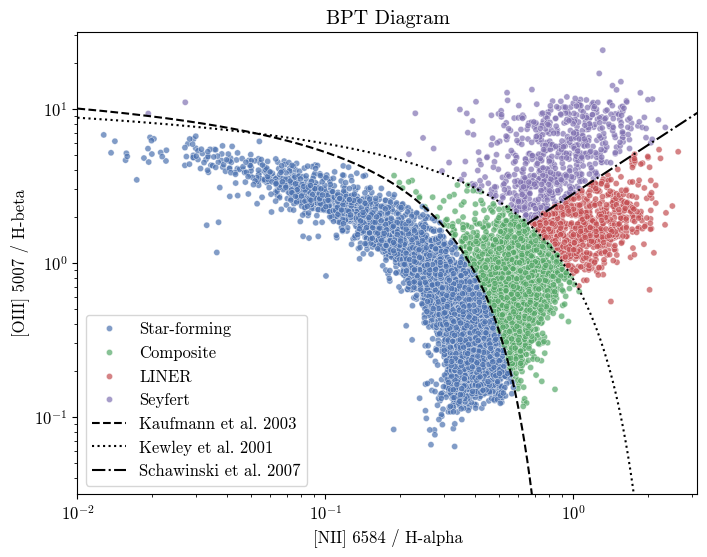

In [6]:
x = np.logspace(-2,0.5,500)
x_kauf = x[x<10**0.05]
x_kew = x[x<10**0.47]
x_schaw = x[x>0.65]

def kauffmann(log_nii_halpha):
    return 0.61 / (log_nii_halpha - 0.05) + 1.3

def kewley(log_nii_halpha):
    return 0.61 / (log_nii_halpha - 0.47) + 1.19

def schawinski(log_nii_halpha):
    return 1.05 * log_nii_halpha + 0.45

# Classification
log_nii = np.log10(result['nii_halpha_ratio'])
log_oiii = np.log10(result['oiii_hbeta_ratio'])
below_kauffmann = (log_nii < 0.05) & (log_oiii < kauffmann(log_nii))
above_kewley    = (log_nii < 0.47) & (log_oiii > kewley(log_nii)) | (log_nii >= 0.47)
above_schawinski = log_oiii > schawinski(log_nii)

sf        = below_kauffmann
agn       = above_kewley & ~sf
composite = ~sf & ~agn
seyfert  = above_kewley & above_schawinski
liners   = above_kewley & ~above_schawinski

result['BPT class'] = 'Unclassified'
result.loc[sf, 'BPT class'] = 'Star-forming'
result.loc[agn, 'BPT class'] = 'AGN'
result.loc[composite, 'BPT class'] = 'Composite'
result.loc[seyfert, 'BPT class'] = 'Seyfert'
result.loc[liners, 'BPT class'] = 'LINER'

plt.figure(figsize=(8,6))
# Data points
sns.scatterplot(result,x='nii_halpha_ratio',y='oiii_hbeta_ratio',hue='BPT class',s=20,alpha=0.7)

# Classification lines
plt.plot(x_kauf,10**(0.61/(np.log10(x_kauf)-0.05)+1.3), color='k', linestyle='--', label='Kaufmann et al. 2003')
plt.plot(x_kew,10**(0.61/(np.log10(x_kew)-0.47)+1.19), color='k', linestyle=':', label='Kewley et al. 2001')
plt.plot(x_schaw,10**(1.05*np.log10(x_schaw)+0.45), color='k', linestyle='-.', label='Schawinski et al. 2007')


# Plot settings
plt.xscale('log')
plt.yscale('log')
plt.xlabel('[NII] 6584 / H-alpha')
plt.ylabel('[OIII] 5007 / H-beta')
plt.xlim(10**-2, 10**0.5)
plt.ylim(10**-1.5, 10**1.5)
plt.title('BPT Diagram')
plt.legend()
plt.show()

In [7]:
print('----- AGN BPT Classification -----\n')
print('Objects Classified as Strong AGN (Seyfert):\n',
      f'Number: {(result["BPT class"] == "Seyfert").sum()}\n',
      f'Percentage: {(result["BPT class"] == "Seyfert").sum() / len(result) * 100:.2f}%')

print('\nObjects Classified as LINERs:\n',
      f'Number: {(result["BPT class"] == "LINER").sum()}\n',
      f'Percentage: {(result["BPT class"] == "LINER").sum() / len(result) * 100:.2f}%')

print('\nTotal objects classified as AGN (Seyfert + LINER):\n',
      f'Number: {(result["BPT class"].isin(["Seyfert", "LINER"])).sum()}\n',
      f'Percentage: {(result["BPT class"].isin(["Seyfert", "LINER"])).sum() / len(result) * 100:.2f}%')

----- AGN BPT Classification -----

Objects Classified as Strong AGN (Seyfert):
 Number: 682
 Percentage: 6.82%

Objects Classified as LINERs:
 Number: 719
 Percentage: 7.19%

Total objects classified as AGN (Seyfert + LINER):
 Number: 1401
 Percentage: 14.01%


b) Make a WHAN diagram

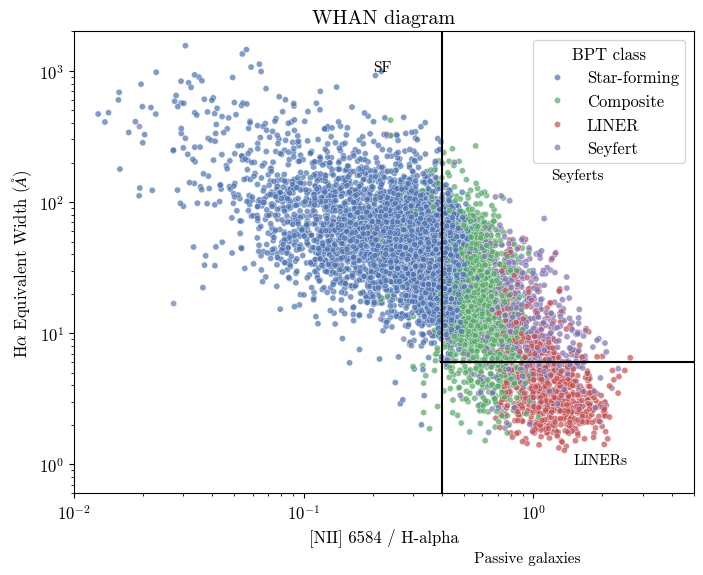

In [9]:
plt.figure(figsize=(8,6))
result['abs_h_alpha_eqw'] = np.abs(result['h_alpha_eqw'])
sns.scatterplot(result,y='abs_h_alpha_eqw',x='nii_halpha_ratio',hue='BPT class',s=20,alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'H$\alpha$ Equivalent Width $(\AA)$')
plt.xlabel('[NII] 6584 / H-alpha')
plt.xlim(0.01, 5)
plt.ylim(0.6, 2e3)

# Classification lines
plt.axvline(x=0.4, color='k')
plt.axhline(y=6,xmin=0.593,xmax=1, color='k') # Seyfert vs LINER
#plt.axhline(y=0.5, xmax=0.59,color='k', linestyle='--', linewidth=1.2)
#plt.axhline(y=0.5, xmin=0.59,color='k', linestyle=':', linewidth=1.2)

# Diagonal line
#xx = np.logspace(np.log10(0.1), np.log10(5), 500)   # linear-space values for log-axis plot
#yy = 0.5 / xx
#plt.plot(xx[xx<1], yy[xx<1], color='k', linestyle=':', linewidth=1.2)
#plt.plot(xx[xx>=1], yy[xx>=1], color='k', linestyle='--', linewidth=1.2)

# Region labels
plt.text(0.2,  1000, 'SF', fontsize=11)
plt.text(1.2,  150, 'Seyferts', fontsize=11)
plt.text(1.5,  1, 'LINERs', fontsize=11)
plt.text(0.55,  0.18, 'Passive galaxies',fontsize=11)

plt.title('WHAN diagram')
plt.show()

In [11]:
# Count objects classified as Seyfert in WHAN diagram that also are Seyfert in BPT diagram
seyfert_whan = (result['nii_halpha_ratio'] > 0.4 ) & (result['abs_h_alpha_eqw'] > 6)
both_seyfert = seyfert_whan & (result['BPT class'] == 'Seyfert')

print('----- WHAN vs BPT Comparison -----\n')

print('Objects classified as Seyfert in WHAN diagram:\n'
      f'Number: {seyfert_whan.sum()}\n'
      f'Percentage: {seyfert_whan.sum() / len(result) * 100:.2f}%\n')

print('Objects classified as Seyfert in both WHAN and BPT diagram:\n'
      f'Number: {both_seyfert.sum()}\n'
      f'Percentage: {both_seyfert.sum() / len(result) * 100:.2f}%')

----- WHAN vs BPT Comparison -----

Objects classified as Seyfert in WHAN diagram:
Number: 3814
Percentage: 38.14%

Objects classified as Seyfert in both WHAN and BPT diagram:
Number: 531
Percentage: 5.31%


# Task 2

In [12]:
query_wise = '''
    SELECT TOP 10000
        s.specobjid,s.z,
        g.oiii_5007_flux,
        g.oiii_sigma,
        g.oi_6300_flux,
        g.h_beta_flux,
        g.h_alpha_flux,
        g.h_alpha_eqw,
        g.sii_6717_flux,
        g.sii_6731_flux,
        g.nii_6584_flux,
        g.oiii_5007_flux / g.h_beta_flux   AS oiii_hbeta_ratio,
        g.nii_6584_flux  / g.h_alpha_flux  AS nii_halpha_ratio,
        w.w1mpro AS w1,
        w.w2mpro AS w2,
        w.w3mpro AS w3,
        w.w1mpro - w.w2mpro AS w1_w2,
        w.w2mpro - w.w3mpro AS w2_w3

    FROM SpecObj AS s
        JOIN GalSpecLine AS g ON s.specobjid = g.specobjid
        LEFT JOIN photoTag    AS p ON s.bestobjid = p.objid
        LEFT JOIN wise_xmatch AS x ON p.objid = x.sdss_objid
                                AND x.match_dist < 3.0
                                AND x.match_dist = (SELECT MIN(match_dist)
                                                    FROM wise_xmatch
                                                    WHERE sdss_objid = p.objid)
        LEFT JOIN wise_allsky AS w ON x.wise_cntr = w.cntr

    WHERE
        s.class      = 'GALAXY' AND
        s.z          < 0.35     AND
        s.snmedian_g > 20       AND

        -- Velocity dispersion (FWHM < 500 km/s)
        2.3548 * g.sigma_balmer < 500 AND
        2.3548 * g.oiii_sigma   < 500 AND

        -- Emission line detection (negative EQW = emission)
        g.oiii_5007_eqw  < -0.1 AND
        g.oi_6300_eqw    < -0.1 AND
        g.h_beta_eqw     < -0.1 AND
        g.h_alpha_eqw    < -0.1 AND
        g.nii_6584_eqw   < -0.1 AND
        g.sii_6717_eqw   < -0.1 AND
        g.sii_6731_eqw   < -0.1 AND

        -- Minimum absolute flux
        g.oiii_5007_flux > 5 AND
        g.oi_6300_flux   > 5 AND
        g.h_beta_flux    > 5 AND
        g.h_alpha_flux   > 5 AND
        g.nii_6584_flux  > 5 AND
        g.sii_6717_flux  > 5 AND
        g.sii_6731_flux  > 5 AND

        -- flux > 5 * flux_err for all diagnostic lines
        g.oiii_5007_flux > 5 * g.oiii_5007_flux_err AND
        g.oi_6300_flux   > 5 * g.oi_6300_flux_err   AND
        g.h_beta_flux    > 5 * g.h_beta_flux_err     AND
        g.h_alpha_flux   > 5 * g.h_alpha_flux_err    AND
        g.nii_6584_flux  > 5 * g.nii_6584_flux_err  AND
        g.sii_6717_flux  > 5 * g.sii_6717_flux_err  AND
        g.sii_6731_flux  > 5 * g.sii_6731_flux_err

        ORDER BY s.specobjid   
'''

result_wise = CasJobs.executeQuery(query_wise, context='DR18')
result_wise.to_csv('agn_sample_wise.csv', index=False)

In [13]:
result_wise = pd.read_csv('agn_sample_wise.csv')
len(result_wise)

10000

In [14]:
result_wise.head()

,specobjid,z,oiii_5007_flux,oiii_sigma,oi_6300_flux,h_beta_flux,h_alpha_flux,h_alpha_eqw,sii_6717_flux,sii_6731_flux,nii_6584_flux,oiii_hbeta_ratio,nii_halpha_ratio,w1,w2,w3,w1_w2,w2_w3
0,299529534741440512,0.052176,86.13953,81.74523,44.57067,266.44600,1334.9670,-36.253700,210.0699,146.98770,489.7381,0.323291,0.366854,12.803,12.539,8.263,0.264001,4.276000
1,299532558398416896,0.021758,780.11430,50.68575,59.05846,638.05270,2292.5280,-56.841010,430.3535,299.65790,465.8451,1.222649,0.203202,13.154,12.935,9.295,0.219000,3.640000
2,299607600067012608,0.025250,49.28839,82.53763,19.15328,70.19812,374.9436,-9.190491,82.4512,54.95967,198.3827,0.702133,0.529100,11.571,11.412,7.727,0.159000,3.684999
3,299638661270497280,0.020076,70.22443,110.51870,48.40514,156.39040,853.0652,-12.626060,187.3937,140.81030,515.1613,0.449033,0.603894,10.826,10.607,6.579,0.219000,4.028000
4,299639211026311168,0.030533,1053.11200,58.27615,62.74306,612.72800,2139.6950,-80.606770,343.9395,244.86470,351.6221,1.718728,0.164333,13.189,12.915,8.966,0.274000,3.949000


In [15]:
# Check if the specobjid in result_wise matches the specobjid in result
matching_ids = set(result['specobjid']).intersection(set(result_wise['specobjid']))
print(f'Matching specobjid count: {len(matching_ids)} / {len(result)}')

Matching specobjid count: 10000 / 10000


In [16]:
# Calculate how many SDSS objects have a WISE match (non-NaN w1)
total        = len(result_wise)                    
wise_matched = result_wise['w1'].notna().sum()     
no_match     = total - wise_matched                

print(f"SDSS objects:        {total}")
print(f"With WISE match:     {wise_matched} ({wise_matched/total*100:.1f}%)")
print(f"No WISE counterpart: {no_match} ({no_match/total*100:.1f}%)")

SDSS objects:        10000
With WISE match:     9612 (96.1%)
No WISE counterpart: 388 (3.9%)


In [17]:
# Do all next steps with only the objects that have a WISE match (non-NaN w1)
result_clean = result_wise[result_wise['w1'].notna()]
result_clean.to_csv('agn_sample_wise_matched.csv', index=False)

In [18]:
len(result_clean)

9612

Wright et al 2012 color-color diagram with Mateos et al 2012 wedge

In [20]:
result_clean = pd.read_csv('agn_sample_wise_matched.csv')
result_clean = result_clean.merge(result[['specobjid', 'BPT class']], on='specobjid', how='left').reset_index(drop=True) # First merge the BPT and WISE classifications

x = result_clean['w2_w3']   # W2 - W3 [Vega mag]
y = result_clean['w1_w2']   # W1 - W2 [Vega mag]

# Mateos et al 2012 wedge boundaries (converted to magnitude space)

def top_boundary(x):    return  0.315 * x + 0.796
def bottom_boundary(x): return  0.315 * x - 0.220
def powerlaw_limit(x):  return -3.172 * x + 7.624

# Wedge selection mask 
in_wedge = (
    (y <  top_boundary(x))    &   # below top line
    (y >  bottom_boundary(x)) &   # above bottom line
    (y >  powerlaw_limit(x))      # above power-law bottom-left limit
)

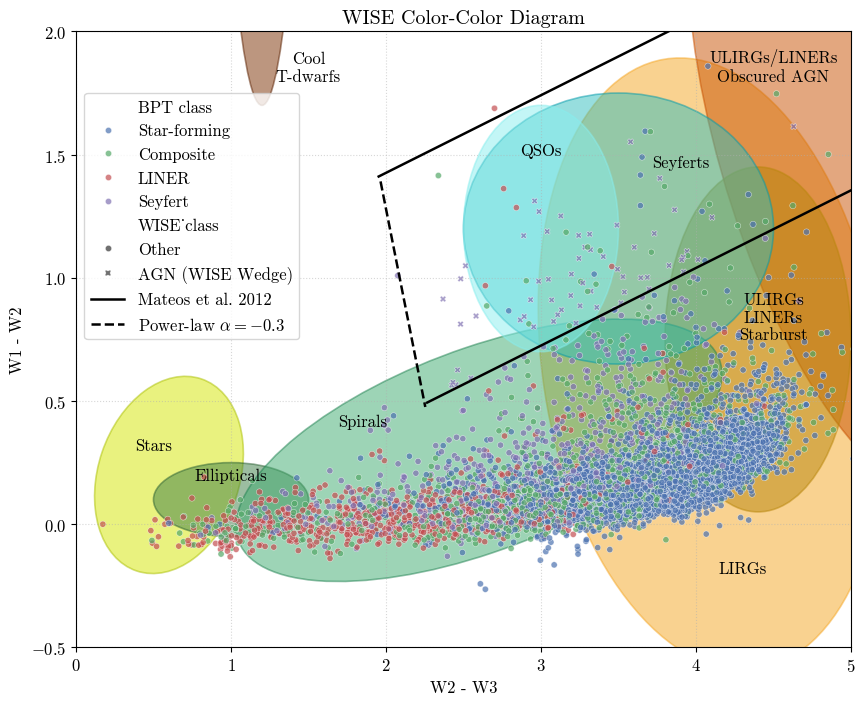

In [22]:
fig, ax = plt.subplots(figsize=(10,8))
ax.set_xlim(0, 5)
ax.set_ylim(-0.5,2)

# Wright et al 2010 Fig.12 blobs
# Each tuple: (center_x, center_y, width, height, angle_deg, facecolor, edgecolor, label)
blobs = [
    # LIRGs
    (4.1, 0.65, 2.6, 2.1, 120, "#F5A623", "#F5A623", 'LIRGs'),
    # ULIRGs / LINERs / Obscured AGN
    (5.0, 1.55, 3.2, 1.6, 120, "#C85000", "#C85000", 'ULIRGs/LINERs Obscured AGN'),
    # ULIRGs / LINERs / Starburst 
    (4.4, 0.75, 1.2, 1.4, 0,   "#B8860B", "#B8860B", 'ULIRGs/LINERs Starburst'),
    # Cool T-dwarfs
    (1.2, 4, 0.55, 4.6, 0,     '#7B2E00', '#5A2000', 'Cool T-dwarfs'),
    # Stars 
    (0.60, 0.20, 1, 0.75, 25,  '#D4E600', '#AABF00', 'Stars'),
    # Ellipticals
    (1, 0.10, 1, 0.3, 0,       "#3A7D44", '#2A5F32', 'Ellipticals'),
    # Spirals
    (2.6, 0.3, 3.2, 0.85, 12,  '#3DAA6E', '#1E8050', 'Spirals'),
    # Seyferts
    (3.5, 1.2, 2, 1.1, 0,      '#30BFBF', '#0099AA', 'Seyferts'),
    # QSOs
    (3, 1.2, 1, 1, 5,           "#88EEEE", "#88EEEE", 'QSOs'),
]

for cx, cy, w, h, ang, fc, ec, lbl in blobs:
    e = Ellipse((cx, cy), width=w, height=h, angle=ang,
                facecolor=fc, edgecolor=ec, alpha=0.5, linewidth=1.2, zorder=1)
    ax.add_patch(e)

ax.text(1.5, 1.8, 'Cool\nT-dwarfs', color='k',ha='center')
ax.text(0.50, 0.30, 'Stars', color='k', ha='center')
ax.text(1.85, 0.4, 'Spirals', color='k', ha='center')
ax.text(1.0, 0.18, 'Ellipticals', color='k', ha='center')
ax.text(3.90, 1.45, 'Seyferts',color='k', ha='center')
ax.text(3.0, 1.5, 'QSOs', color='k', ha='center')
ax.text(4.5, 1.8, 'ULIRGs/LINERs\nObscured AGN',color='k', ha='center')
ax.text(4.5, 0.75, 'ULIRGs\nLINERs\nStarburst',color='k', ha='center')
ax.text(4.30, -0.20, 'LIRGs', color='k', ha='center')

# Add special marker for objects inside the Mateos wedge and marked as AGN in BPT
wedge_agn = in_wedge & (result_clean['BPT class'] == 'Seyfert')
result_clean['WISE_class'] = 'Other'
result_clean.loc[wedge_agn, 'WISE_class'] = 'AGN (WISE Wedge)'

# Objects from our sample with BPT classification
sns.scatterplot(data=result_clean, x='w2_w3', y='w1_w2',hue='BPT class',style='WISE_class', s=20,alpha=0.7)

# Matteos et al 2012 Wedge boundaries
x_range = np.linspace(-0.5, 5.5, 500)
ax.plot(x_range[x_range>1.95], top_boundary(x_range[x_range>1.95]),    'k',  lw=1.8, label='Mateos et al. 2012')
ax.plot(x_range[x_range>2.26], bottom_boundary(x_range[x_range>2.26]), 'k', lw=1.8)
ax.plot(x_range[(x_range>1.96) & (x_range<2.26)], powerlaw_limit(x_range[(x_range>1.96) & (x_range<2.26)]),  'k--',  lw=1.8, label=r'Power-law $\alpha = -0.3$')

# Plot settings
ax.set_ylabel('W1 - W2')
ax.set_xlabel('W2 - W3')
ax.set_title('WISE Color-Color Diagram')
plt.legend(loc='center left', bbox_to_anchor=(0, 0.7))
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

In [23]:
print('----- WISE Color-Color Diagram Analysis -----\n')

print("Objects inside Mateos wedge (Classified as AGN by WISE):\n"
      f'Number: {in_wedge.sum()}\n'
      f'Percentage: {in_wedge.sum() / len(result_clean) * 100:.2f}%')

print("\nObjects inside Mateos wedge that are also Strong AGN (Seyfert) in BPT diagram:\n"
      f'Number: {wedge_agn.sum() }\n'
      f'Percentage: {wedge_agn.sum() / len(result_clean) * 100:.2f}%')

----- WISE Color-Color Diagram Analysis -----

Objects inside Mateos wedge (Classified as AGN by WISE):
Number: 95
Percentage: 0.99%

Objects inside Mateos wedge that are also Strong AGN (Seyfert) in BPT diagram:
Number: 59
Percentage: 0.61%


**Summary of AGN Classification with SDSS and WISE**

- From *10000* objects, 1401 were classified as AGN from the Kewly and Kaufmann lines. From this **682** were classified as Strong AGN (Seyferts).
- Then from the WHAN diagram 3814 objects are classified as Seyferts and **531** are Seyferts in both BPT and WHAN diagrams.
- Next, using the WISE color-color digram and the Mateos et al wedge, 95 objects are classified as AGN. Only **59** of these are also strong AGN (Seyferts) in the BPT diagram.

# Task 3

In [25]:
def ne(R_si):
    a = 0.4315
    b = 2107.0
    c = 627.1
    return (c*R_sii - a*b) / (a - R_sii)

R_sii = result_clean['sii_6717_flux'] / result_clean['sii_6731_flux']

result_clean['n_e'] = ne(R_sii)

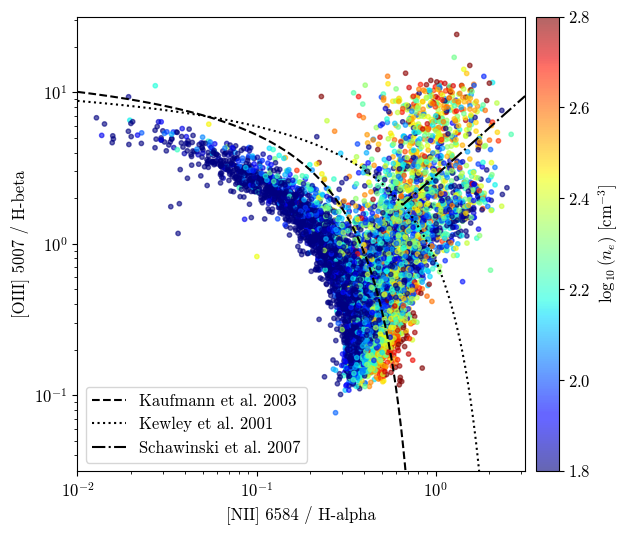

In [28]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

sc = ax.scatter(result_clean['nii_halpha_ratio'], result_clean['oiii_hbeta_ratio'],
    c=np.log10(result_clean['n_e']),
    cmap="jet",         
    vmin=1.8, vmax=2.8,
    s=10,                 
    alpha=0.6,
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$\log_{10}(n_e)$ [cm$^{-3}$]")

# Classification lines
ax.plot(x_kauf,10**(0.61/(np.log10(x_kauf)-0.05)+1.3), color='k', linestyle='--', label='Kaufmann et al. 2003')
ax.plot(x_kew,10**(0.61/(np.log10(x_kew)-0.47)+1.19), color='k', linestyle=':', label='Kewley et al. 2001')
ax.plot(x_schaw,10**(1.05*np.log10(x_schaw)+0.45), color='k', linestyle='-.', label='Schawinski et al. 2007')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(10**-2, 10**0.5)
ax.set_ylim(10**-1.5, 10**1.5)
ax.set_xlabel('[NII] 6584 / H-alpha')
ax.set_ylabel('[OIII] 5007 / H-beta')
ax.legend()


plt.tight_layout()
plt.show()

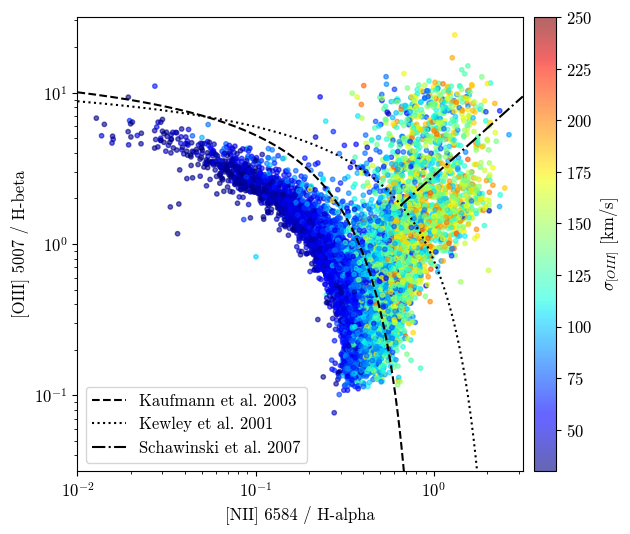

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

sc = ax.scatter(result_clean['nii_halpha_ratio'], result_clean['oiii_hbeta_ratio'],
    c=result_clean['oiii_sigma'],
    cmap="jet",         
    vmin=30, vmax=250,
    s=10,                 
    alpha=0.6,
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$\sigma_{[OIII]}$ [km/s]")

# Classification lines
ax.plot(x_kauf,10**(0.61/(np.log10(x_kauf)-0.05)+1.3), color='k', linestyle='--', label='Kaufmann et al. 2003')
ax.plot(x_kew,10**(0.61/(np.log10(x_kew)-0.47)+1.19), color='k', linestyle=':', label='Kewley et al. 2001')
ax.plot(x_schaw,10**(1.05*np.log10(x_schaw)+0.45), color='k', linestyle='-.', label='Schawinski et al. 2007')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(10**-2, 10**0.5)
ax.set_ylim(10**-1.5, 10**1.5)
ax.set_xlabel('[NII] 6584 / H-alpha')
ax.set_ylabel('[OIII] 5007 / H-beta')
ax.legend()


plt.tight_layout()
plt.show()

In [29]:
def MBH(sigma_oiii):
    return 10**8.13 * (sigma_oiii / 200)**4.02

result_clean['log_MBH'] = np.log10(MBH(result_clean['oiii_sigma']))

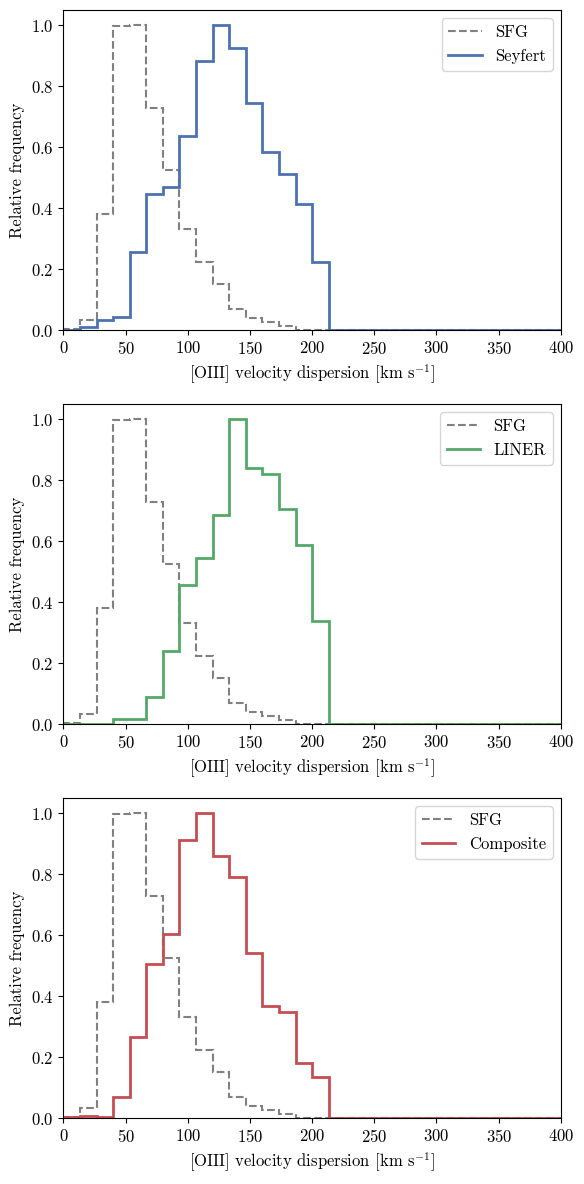

In [46]:
classes   = ['Seyfert', 'LINER', 'Composite']
colors    = ['C0', 'C1', 'C2']
sfg       = result_clean[result_clean['BPT class'] == 'Star-forming']

fig, axes = plt.subplots(3, 1, figsize=(6, 12))

for ax, cls, color in zip(axes, classes, colors):
    grp = result_clean[result_clean['BPT class'] == cls]

    # Compute histograms manually so we can normalize to peak (relative frequency)
    bins = np.linspace(0, 400, 31)

    sfg_counts, edges = np.histogram(sfg['oiii_sigma'], bins=bins)
    cls_counts, _     = np.histogram(grp['oiii_sigma'], bins=bins)

    sfg_norm = sfg_counts / sfg_counts.max()
    cls_norm = cls_counts / cls_counts.max()

    ax.stairs(sfg_norm, edges, color='grey',  linestyle='--', linewidth=1.5, label='SFG')
    ax.stairs(cls_norm, edges, color=color,   linestyle='-',  linewidth=2.0, label=cls)

    ax.set_xlim(0, 400)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(r'[OIII] velocity dispersion [km s$^{-1}$]')
    ax.set_ylabel('Relative frequency')
    ax.legend()

plt.tight_layout()
plt.show()

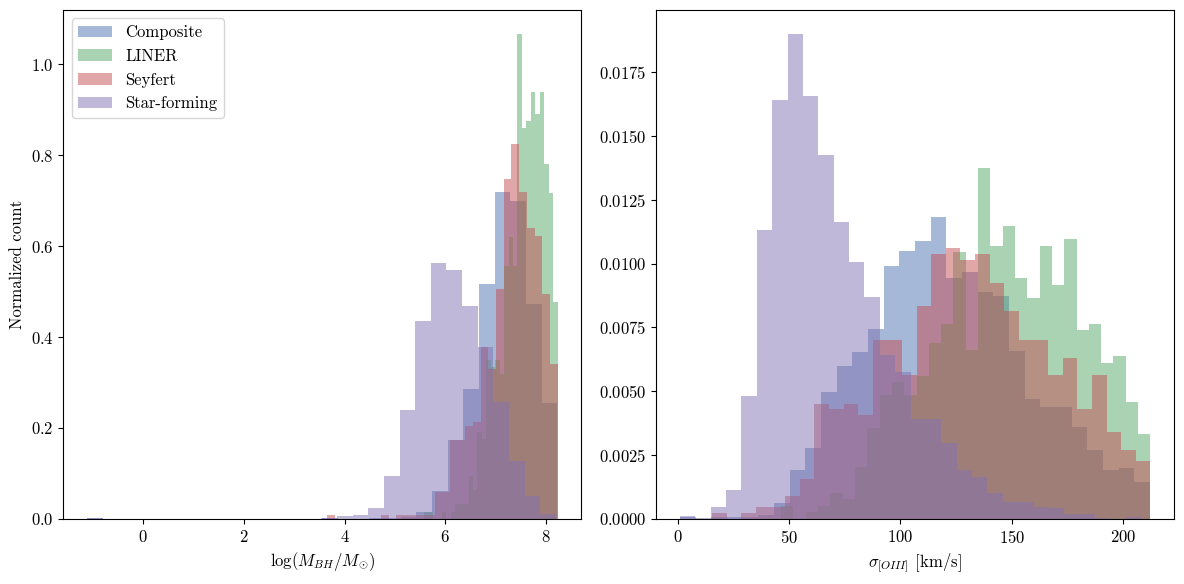

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

cols = ['log_MBH', 'oiii_sigma']
labels = [r'$\log(M_{BH} / M_{\odot})$', r'$\sigma_{[OIII]}$ [km/s]']


for label, group in result_clean.groupby('BPT class'):
    axes[0].hist(group[cols[0]], bins=30, alpha=0.5, label=label, density=True)
axes[0].set_xlabel(labels[0])

for label, group in result_clean.groupby('BPT class'):
    axes[1].hist(group[cols[1]], bins=30, alpha=0.5, label=label, density=True)
axes[1].set_xlabel(labels[1])

axes[0].set_ylabel('Normalized count')
axes[0].legend()

plt.tight_layout()
plt.show()

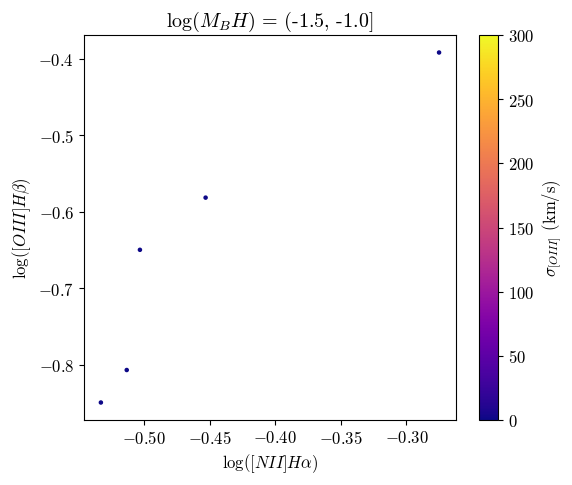

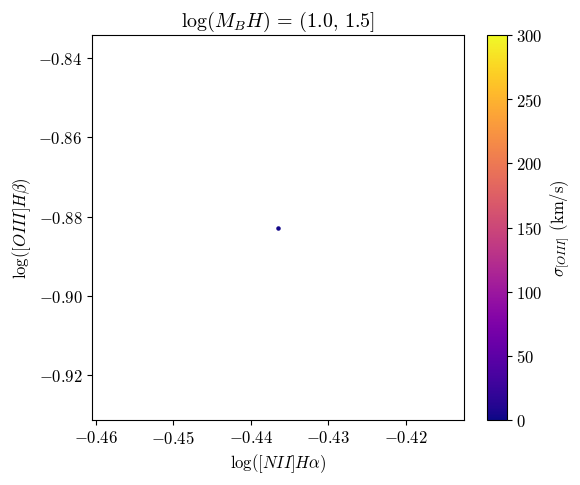

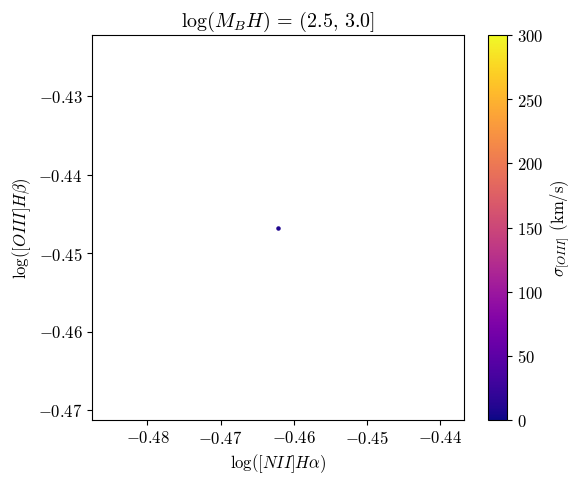

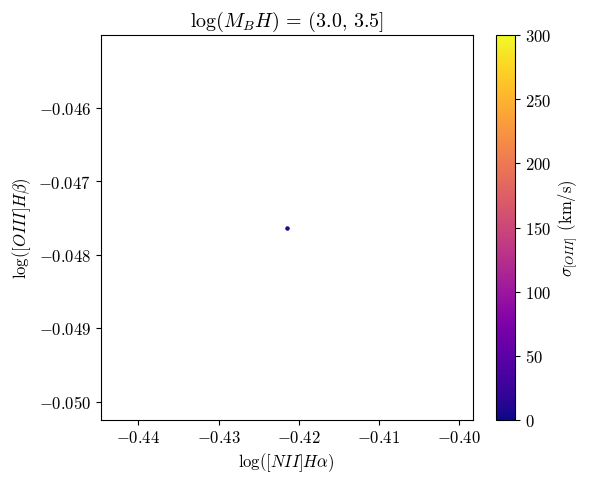

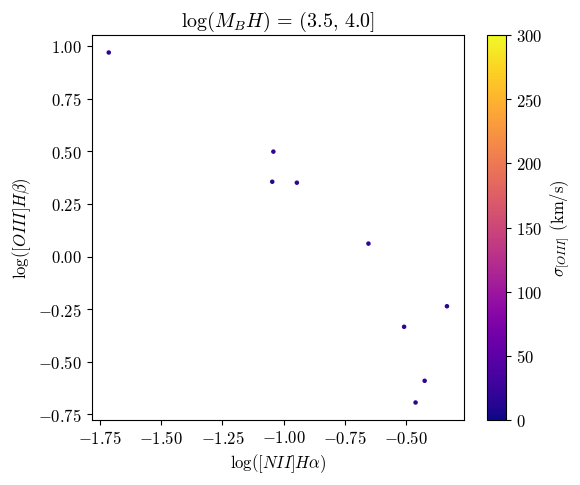

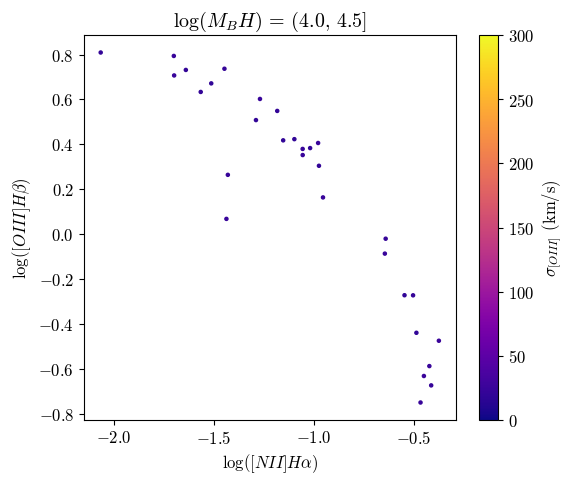

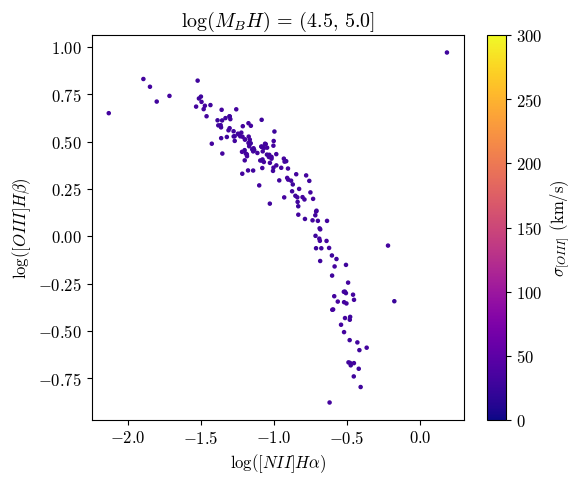

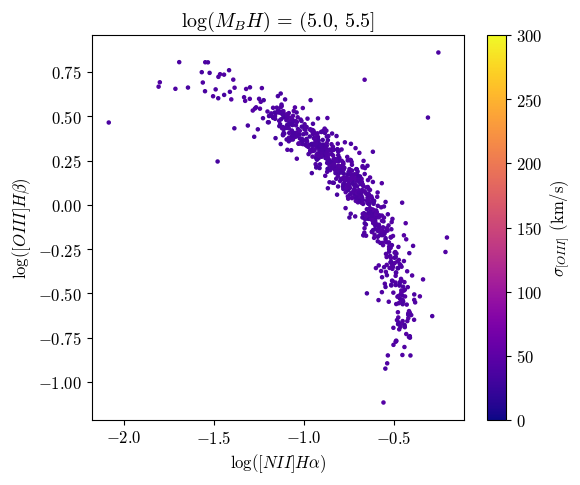

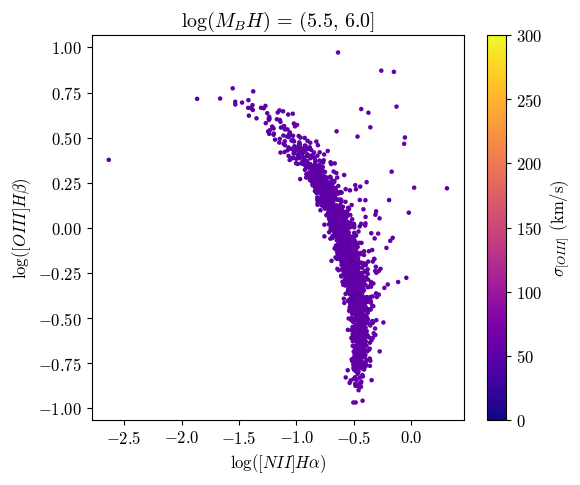

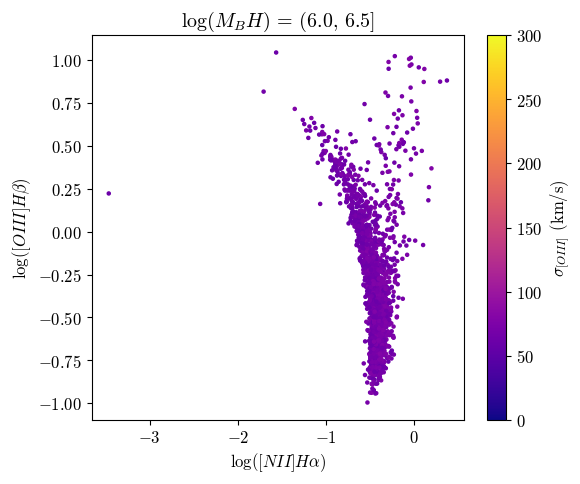

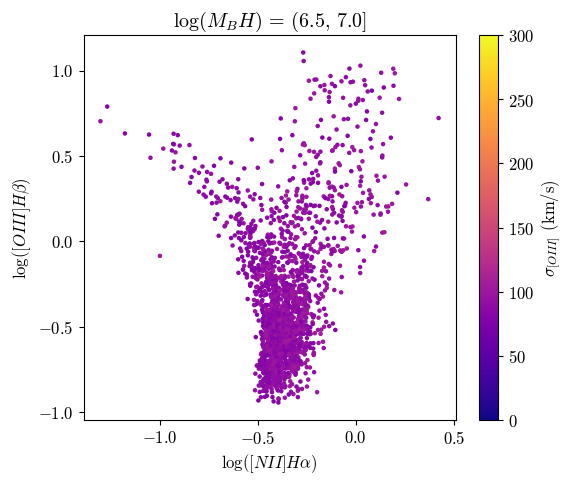

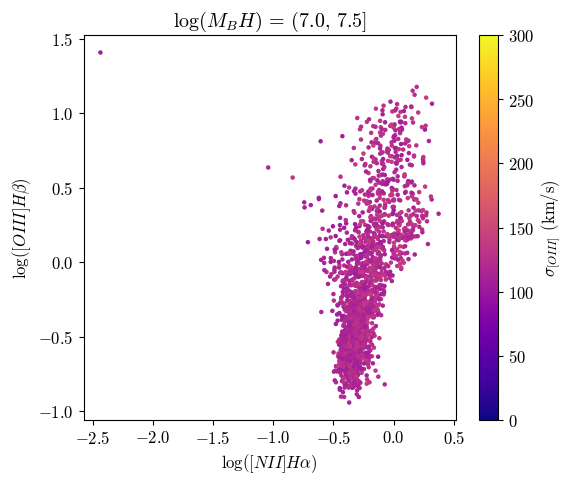

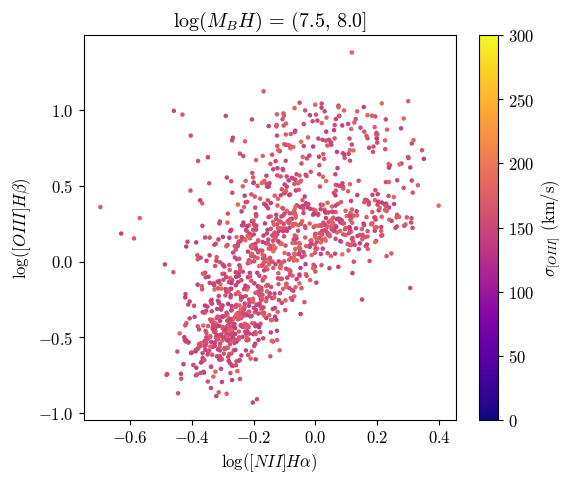

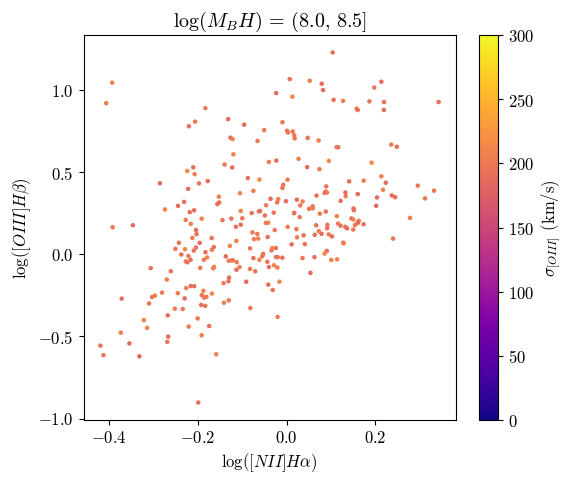

In [43]:
# Define bins of 0.5 dex in log(M_BH)
mbh_min = result_clean['log_MBH'].min()
mbh_max = result_clean['log_MBH'].max()
bins = np.arange(np.floor(mbh_min), np.ceil(mbh_max) + 0.5, 0.5)  # 0.5 dex bins

result_clean['mbh_bin'] = pd.cut(result_clean['log_MBH'], bins=bins)

# One BPT panel per mass bin, coloured by oiii_sigma_kms
for bin_label, group in result_clean.groupby('mbh_bin'):
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(
        np.log10(group['nii_halpha_ratio']),
        np.log10(group['oiii_hbeta_ratio']),
        c=group['oiii_sigma'], cmap='plasma',
        s=5, vmin=0, vmax=300
    )
    plt.colorbar(sc, label=r'$\sigma_{[OIII]}$ (km/s)')
    plt.title(fr'$\log(M_BH)$ = {bin_label}')
    plt.xlabel(r'$\log([NII]H\alpha)$')
    plt.ylabel(r'$\log([OIII]H\beta)$')
    # add Kewley/Kauffmann lines...
    plt.show()